In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
import pandas as pd
import seaborn as sns
from mne.stats import permutation_cluster_test
from mpl_toolkits.mplot3d import Axes3D
import scipy.io as sio
import os
from scipy import stats
from collections import defaultdict


In [4]:
# Stier
bdf_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf"
csv_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/data_p9876_20260508_1018.csv"

# Indlæsning af data
raw = mne.io.read_raw_bdf(bdf_path, preload=True)   # .bdf
raw.resample(256)
raw = raw.notch_filter(50)
raw.set_eeg_reference('average', projection=False)
df = pd.read_csv(csv_path)                          # .csv

Extracting BDF parameters from C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf...


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6557695  =      0.000 ...  3202.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

In [ ]:
# ICA (Independent Component Analysis) For at fjerne øjenblink
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_ica, decim=3)

# Bed MNE om automatisk at finde blink vha. de forreste elektroder.
eog_channels = ['Fp1', 'Fp2', 'Fpz']
try:
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
    print(f"ICA fandt blink i komponent(er): {eog_indices}")
    ica.exclude = eog_indices
except Exception as e:
    print(f"Kunne ikke finde EOG automatisk (tjek elektrodenavne). Kør ica.plot_components(raw) for at vælge manuelt.")

# Filtrer den RIGTIGE data til ERP-brug (0.1 - 30 Hz) og træk blink-komponenterne ud
raw_clean = raw.copy().filter(l_freq=0.1, h_freq=40.0)
ica.apply(raw_clean)

# Find triggers
events = mne.find_events(raw_clean, stim_channel='Status')

# Sikkerhedstjek: Antal triggers fra EEG skal matche antal trials i CSV
if len(events) > len(df):
    print("Fandt ekstra start/stop triggers i EEG'et. Fjerner dem for at matche CSV...")
    events = events[-len(df):]

tmin, tmax = -0.2, 0.8
reject_criteria = dict(eeg=150e-6)

epochs = mne.Epochs(
    raw_clean,
    events,
    metadata = df,
    #event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=(tmin, 0), # Nulstil baseline (-0.2 til 0) så alle starter samme sted
    preload=True,
    reject=reject_criteria
)

# Hvilke epochs der er droppet efter ICA
print(epochs.drop_log_stats())


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 16.6s.
Using EOG channels: Fp1, Fp2, Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- L

In [6]:
blocks_to_exclude = [1,2,3,4,5,6,7,11,15,19,23,27] #1,2,3,4,5,6 (Training) ,7,11,15,19,23,27 (Habituation)
epochs_main = epochs[f"block_num not in {blocks_to_exclude}"]
epochs_correct = epochs_main["correct == True"]
print(f"Beholder {len(epochs_correct)} trials til selve ERP analysen.")

Beholder 998 trials til selve ERP analysen.


In [7]:
num_deviants = len(epochs_correct["stimulus_state == 'deviant'"])
num_standards = len(epochs_correct["stimulus_state == 'standard'"])

print(f"\nUd af {len(epochs_correct)} korrekte trials:")
print(f"- Standard trials: {num_standards}")
print(f"- Deviant trials: {num_deviants}")

print("\nFordeling af deviants per type og blok-betingelse:")
deviant_metadata = epochs_correct.metadata[epochs_correct.metadata['stimulus_state'] == 'deviant']
print(deviant_metadata.groupby(['block_type', 'deviant_type']).size().reset_index(name='antal'))


Ud af 998 korrekte trials:
- Standard trials: 844
- Deviant trials: 154

Fordeling af deviants per type og blok-betingelse:
  block_type deviant_type  antal
0    Dynamic           AS     27
1    Dynamic           AV     23
2    Dynamic           SV     24
3     Static           AS     27
4     Static           AV     33
5     Static           SV     20


Using a threshold of 3.852182
stat_fun(H1): min=2.9199663858483606e-06 max=12.283930108259225
Running initial clustering …
Found 11 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
C:\Users\lundb\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Permuting : 999/999 [00:05<00:00,  179.21it/s]


Using a threshold of 3.852182


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


stat_fun(H1): min=4.510373612965336e-05 max=15.379774315243502
Running initial clustering …
Found 7 clusters


100%|██████████| Permuting : 999/999 [00:05<00:00,  178.93it/s]


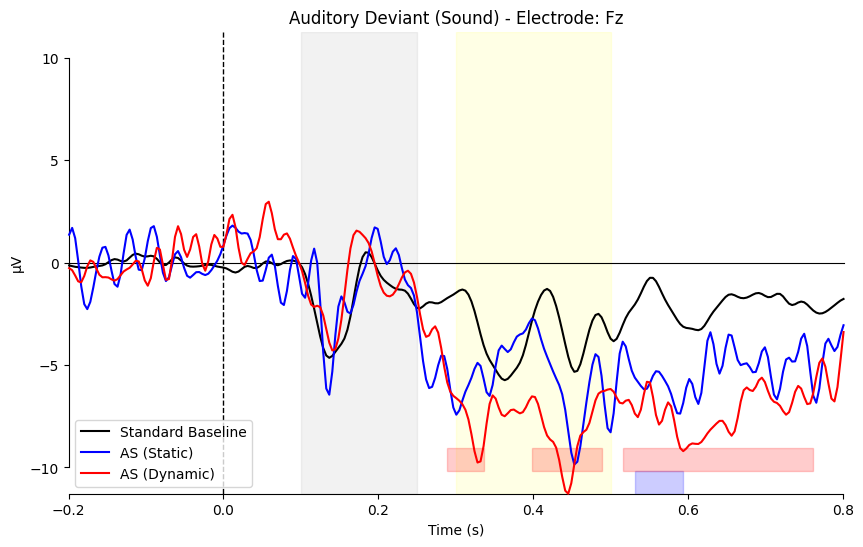

Using a threshold of 3.852182
stat_fun(H1): min=1.0628214629496219e-05 max=8.669002232760576
Running initial clustering …
Found 2 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:07<00:00,  139.05it/s]

Using a threshold of 3.852182



C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


stat_fun(H1): min=0.0003033786230974039 max=12.163067813482158
Running initial clustering …
Found 3 clusters


100%|██████████| Permuting : 999/999 [00:06<00:00,  160.90it/s]


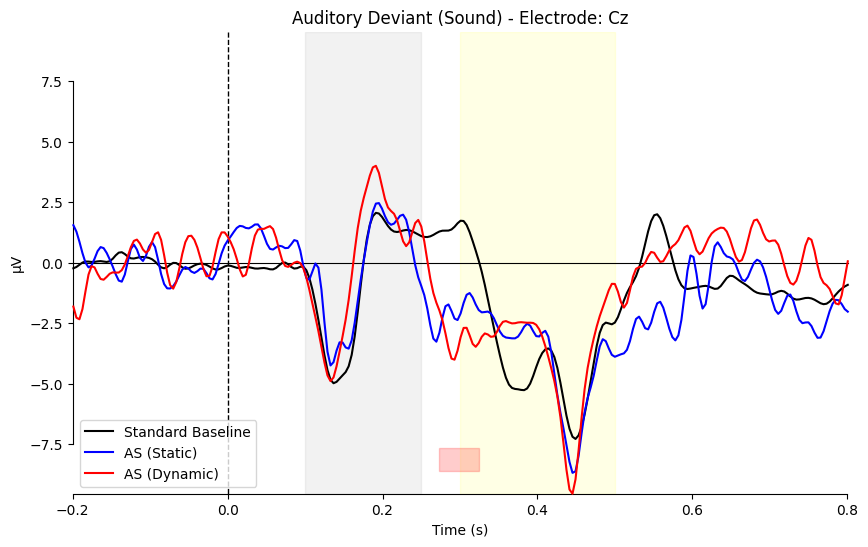

Using a threshold of 3.852269
stat_fun(H1): min=1.662232736091956e-07 max=11.000657236516897
Running initial clustering …
Found 8 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:04<00:00,  220.98it/s]
C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


Using a threshold of 3.852219
stat_fun(H1): min=0.0007849433735155587 max=79.98402015539273
Running initial clustering …
Found 9 clusters


100%|██████████| Permuting : 999/999 [00:06<00:00,  166.37it/s]


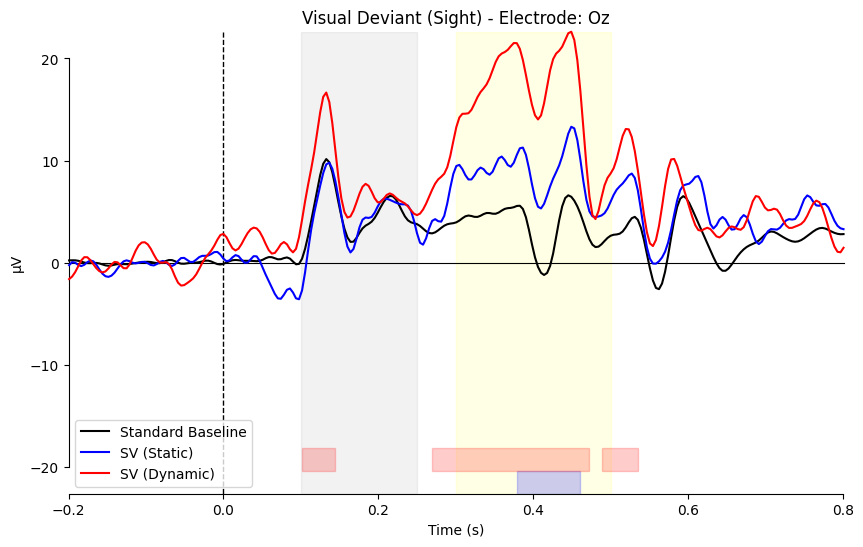

Using a threshold of 3.852269
stat_fun(H1): min=0.0005845211550465244 max=8.36666891449766
Running initial clustering …
Found 9 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:06<00:00,  153.28it/s]
C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


Using a threshold of 3.852219
stat_fun(H1): min=0.0009689595667022728 max=48.33382196547457
Running initial clustering …
Found 5 clusters


100%|██████████| Permuting : 999/999 [00:05<00:00,  178.00it/s]


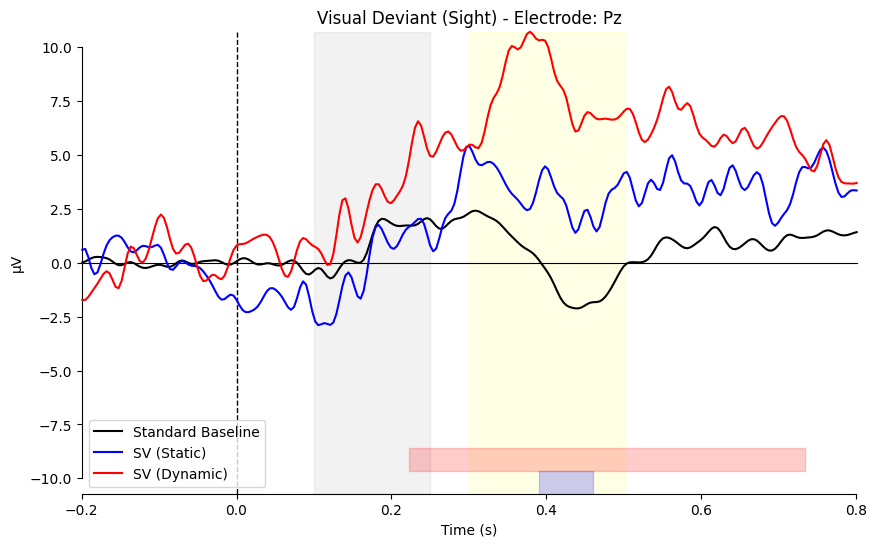

Using a threshold of 3.852108
stat_fun(H1): min=1.4274424710620866e-06 max=9.741888500506752
Running initial clustering …
Found 4 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:03<00:00,  269.61it/s]


Using a threshold of 3.852232
stat_fun(H1): min=4.624174861867253e-05 max=8.997289558568474
Running initial clustering …
Found 9 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  399.36it/s]


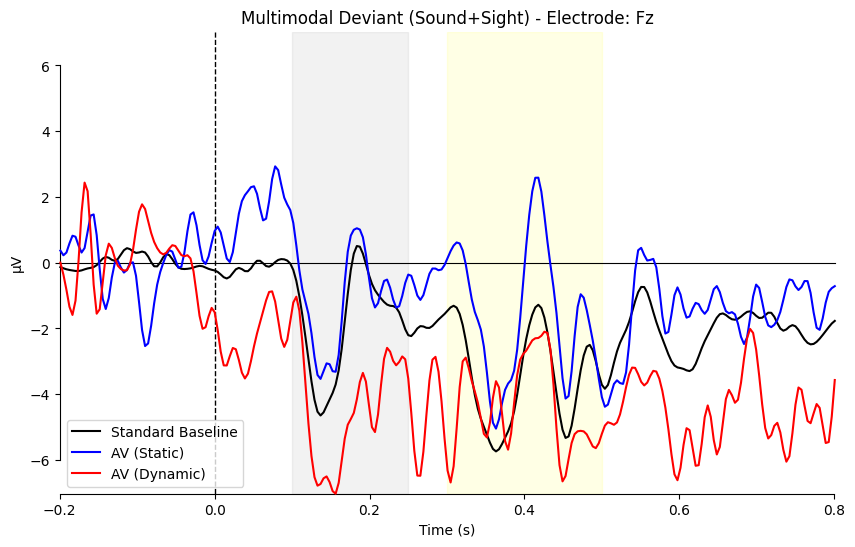

C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


Using a threshold of 3.852108
stat_fun(H1): min=6.825260097315789e-06 max=5.834884949339288
Running initial clustering …
Found 2 clusters


100%|██████████| Permuting : 999/999 [00:02<00:00,  395.42it/s]


Using a threshold of 3.852232
stat_fun(H1): min=7.19191454743418e-06 max=10.241276788473124
Running initial clustering …
Found 5 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  427.38it/s]


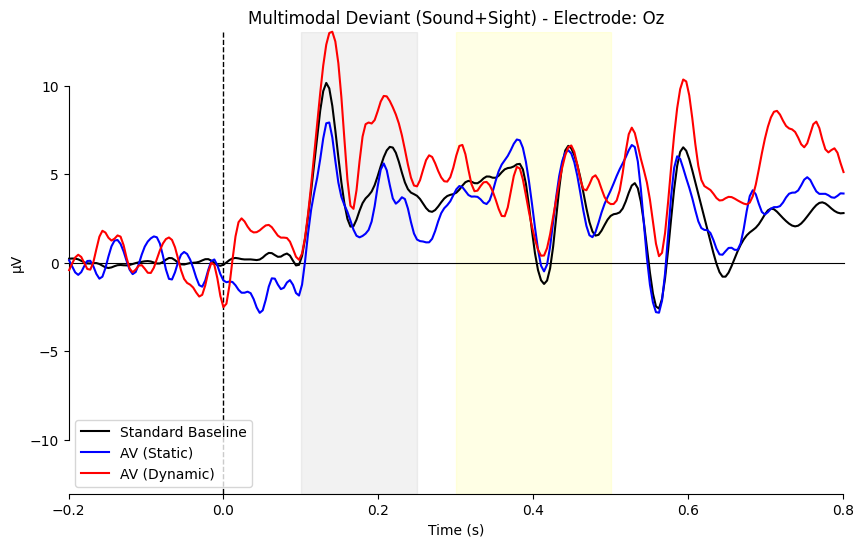

C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")


Using a threshold of 3.852108
stat_fun(H1): min=0.00011224634330236202 max=7.5188461168597
Running initial clustering …
Found 3 clusters


100%|██████████| Permuting : 999/999 [00:02<00:00,  363.45it/s]


Using a threshold of 3.852232
stat_fun(H1): min=3.419748614872319e-05 max=12.613258062210871
Running initial clustering …
Found 4 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  430.75it/s]


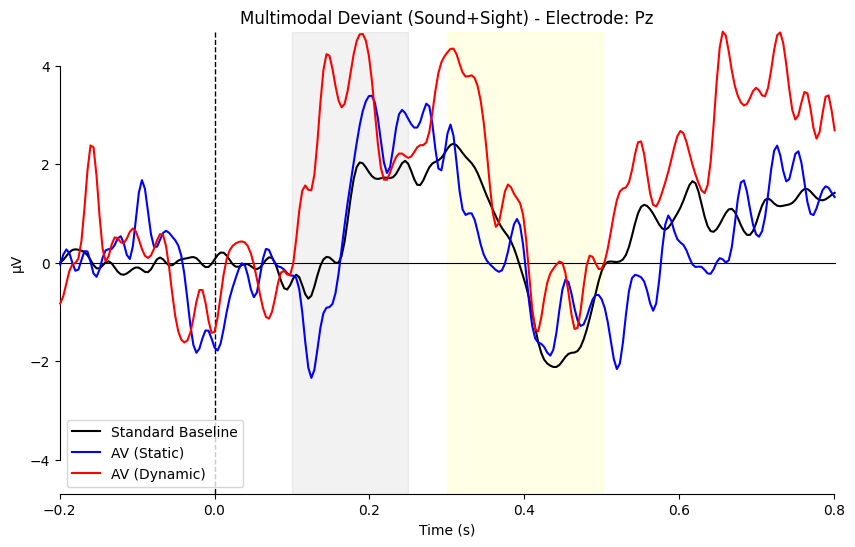

In [8]:
# ==========================================
# 7. ERP PLOTS MED SIGNIFIKANS
# ==========================================

cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

deviant_configs = {
    'AS': {
        'name': 'Auditory Deviant (Sound)',
        'channels': ['Fz', 'Cz']
    },
    'SV': {
        'name': 'Visual Deviant (Sight)',
        'channels': ['Oz', 'Pz']
    },
    'AV': {
        'name': 'Multimodal Deviant (Sound+Sight)',
        'channels': ['Fz', 'Oz', 'Pz']
    }
}

for dev_type, config in deviant_configs.items():

    # Epoch-dataen 
    epochs_static = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_std = epochs_correct["stimulus_state == 'standard'"]

    # Gennemsnittet
    cond_static = epochs_static.average()
    cond_dynamic = epochs_dyn.average()

    evokeds_dict = {
        'Standard Baseline': cond_standard,
        f'{dev_type} (Static)': cond_static,
        f'{dev_type} (Dynamic)': cond_dynamic
    }

    colors = {
        'Standard Baseline': 'black',
        f'{dev_type} (Static)': 'blue',
        f'{dev_type} (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            mne.viz.plot_compare_evokeds(
                evokeds_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} - Electrode: {ch}",
                show_sensors=False,
                show=False 
            )

            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, zorder=0)

            ch_idx = epochs_correct.ch_names.index(ch)
            times = epochs_correct.times

            # Data arrays til klyngetesten
            data_std = epochs_std.get_data(picks=ch_idx).squeeze()
            data_stat = epochs_static.get_data(picks=ch_idx).squeeze()
            data_dyn = epochs_dyn.get_data(picks=ch_idx).squeeze()

            # Test: Er static signifikant forskellig fra Standard?
            _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
            if clusters_stat: # Tjek om den fandt nogle clusters
                for i_c, c in enumerate(clusters_stat):
                    if p_val_stat[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='blue', alpha=0.2, ymin=0.0, ymax=0.05)

            # Test: Er dynamic signifikant forskellig fra Standard?
            _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
            if clusters_dyn: # Tjek om den fandt nogle clusters
                for i_c, c in enumerate(clusters_dyn):
                    if p_val_dyn[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='red', alpha=0.2, ymin=0.05, ymax=0.1)

            # Opdater legend og vis grafen
            # For at undgå at signifikans-boksene står 5 gange i boksen, fjerner vi dubletter
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner antal faktiske afvigere i dataen for alle betingelser...

--- FAKTISK ANTAL DEVIANTS I DATAEN ---
block_type deviant_type  Antal
   Dynamic           AS     27
   Dynamic           AV     23
   Dynamic           SV     24
    Static           AS     27
    Static           AV     33
    Static           SV     20


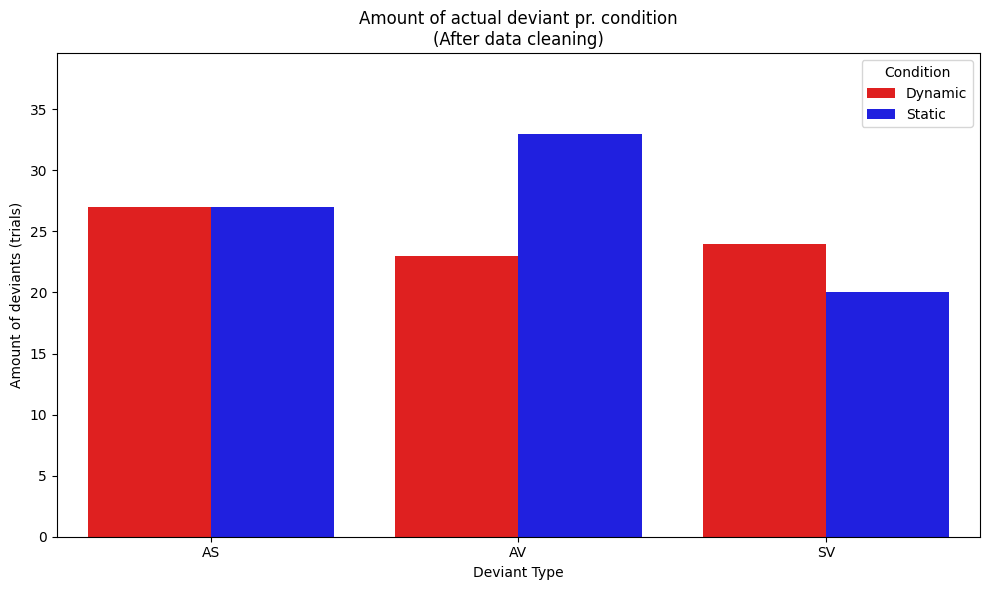

In [9]:
# ==========================================
# 8. TJEK ANTAL DEVIANTS (STATISK VS DYNAMISK)
# ==========================================
print("\nBeregner antal faktiske afvigere i dataen for alle betingelser...")

# Træk den underliggende pandas DataFrame ud fra vores rensede epochs
df_main = epochs_correct.metadata

# Filtrer, så vi KUN kigger på trials, der faktisk var deviants
df_deviants = df_main[df_main['stimulus_state'] == 'deviant']

# Tæl hvor mange der er af hver kombination (block_type x deviant_type)
counts = df_deviants.groupby(['block_type', 'deviant_type']).size().reset_index(name='Antal')

# Print de rå tal i konsollen (Rigtig godt til metodeafsnittet!)
print("\n--- FAKTISK ANTAL DEVIANTS I DATAEN ---")
print(counts.to_string(index=False))

# Lav et flot grupperet bar-plot
plt.figure(figsize=(10, 6))

# Brug 'hue' til at farvekode Statisk/Dynamisk og 'x' til at dele op i AV, SV, AS
sns.barplot(
    data=counts,
    x='deviant_type',
    y='Antal',
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'}
)

plt.title('Amount of actual deviant pr. condition\n(After data cleaning)')
plt.ylabel('Amount of deviants (trials)')
plt.xlabel('Deviant Type')

# Sæt y-aksen til at starte ved 0 og give lidt luft i toppen
plt.ylim(0, max(counts['Antal']) * 1.2)

# Gør 'legend' (signaturforklaringen) pænere
plt.legend(title='Condition', loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 9. MARKOV KÆDER: HAZARD RATE PÅ P300
# ==========================================
import copy

# 1. Frasorter fejl-trials først! (Guldstandard)
epochs_correct = epochs_main["correct == True"]

# 2. Hent metadataen for at tilføje vores tæller
m = epochs_correct.metadata.copy()

# 3. Kør igennem alle trials og tæl hvor mange standarder, der har været i træk
run_lengths = []
current_run = 0

for state in m['stimulus_state']:
    if state == 'standard':
        current_run += 1
        run_lengths.append(current_run)
    else: # Hvis det er en deviant
        # Gem hvor mange standarder der kom LIGE FØR denne deviant
        run_lengths.append(current_run)
        current_run = 0 # Nulstil tælleren

# Tilføj den nye kolonne til vores metadata
m['run_length'] = run_lengths
epochs_correct.metadata = m

Replacing existing metadata with 11 columns



Beregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...

--- Genererer ROI plots for Auditory Deviant (Sound) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


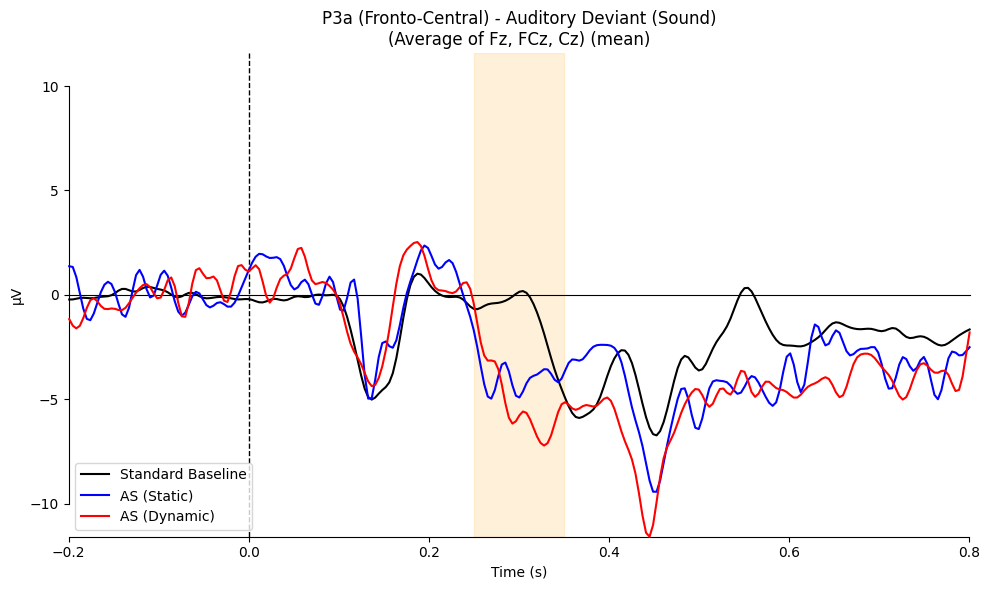

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


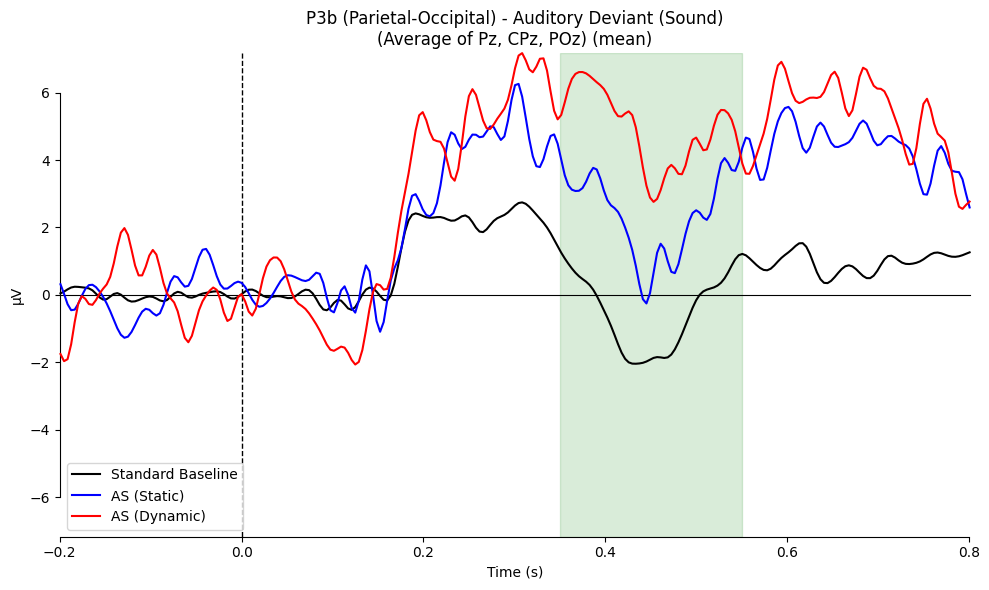


--- Genererer ROI plots for Visual Deviant (Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


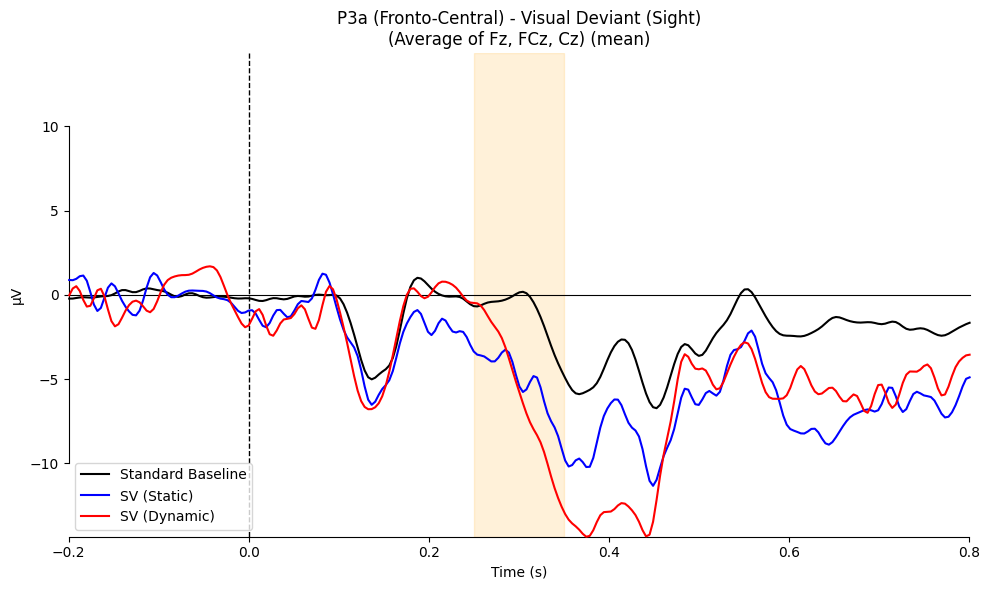

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


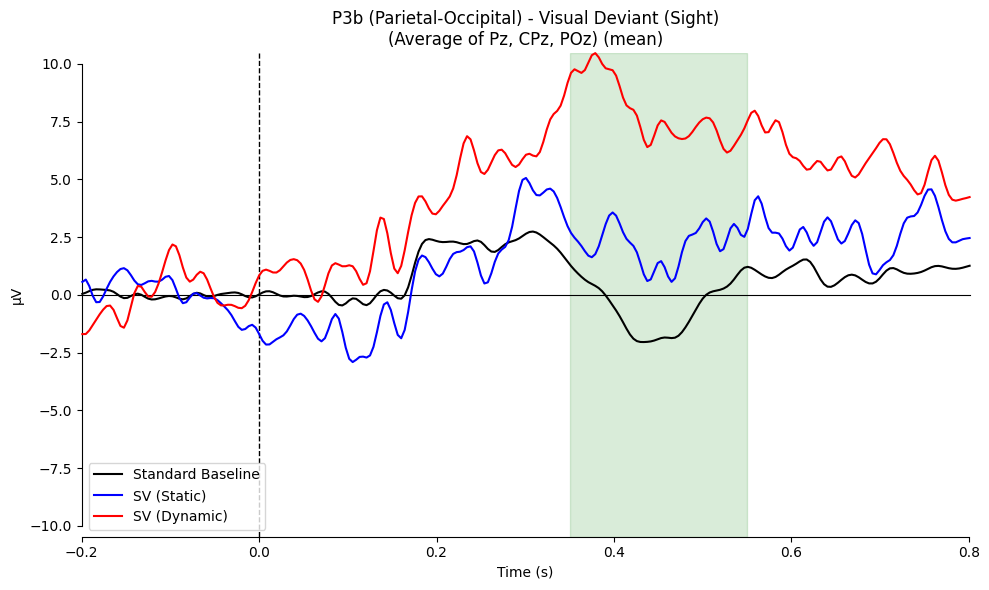


--- Genererer ROI plots for Multimodal Deviant (Sound+Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


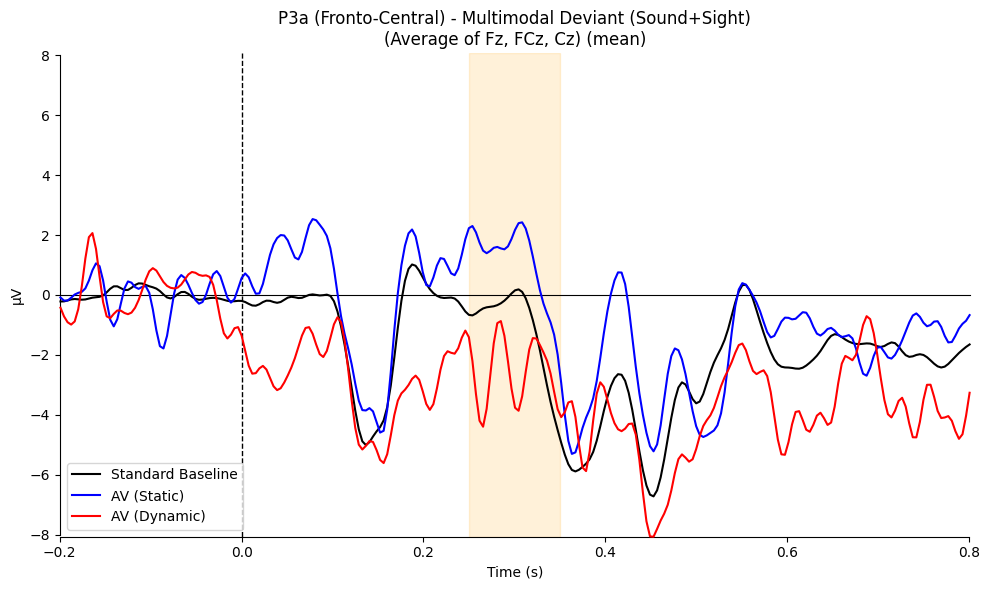

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


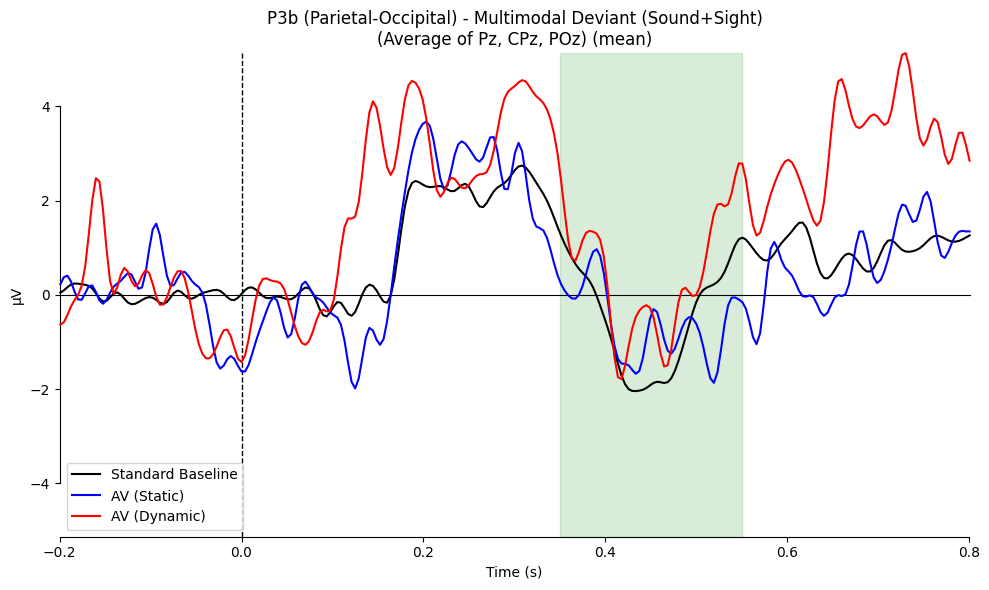

In [15]:
# ==========================================
# 13. P3a vs P3b (Region of Interest Analyse)
# ==========================================
import mne
import matplotlib.pyplot as plt

print("\nBeregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...")

# 1. Definer vores to Regions of Interest (ROI)
rois = {
    'P3a (Fronto-Central)': ['Fz', 'FCz', 'Cz'],
    'P3b (Parietal-Occipital)': ['Pz', 'CPz', 'POz']
}

# 2. Opsætning af de tre afvigertyper
deviant_names = {
    'AS': 'Auditory Deviant (Sound)',
    'SV': 'Visual Deviant (Sight)',
    'AV': 'Multimodal Deviant (Sound+Sight)'
}

# Hent standard-baselinen (den er ens for alle plots)
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# 3. Loop over hver afvigertype (AS, SV, AV)
for dev_type, dev_name in deviant_names.items():
    print(f"\n--- Genererer ROI plots for {dev_name} ---")
    
    # Hent Statisk og Dynamisk for netop denne afviger
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # Saml dem i en ordbog
    evokeds_dict = {
        'Standard Baseline': evoked_std,
        f'{dev_type} (Static)': evoked_stat,
        f'{dev_type} (Dynamic)': evoked_dyn
    }

    colors = {
        'Standard Baseline': 'black', 
        f'{dev_type} (Static)': 'blue', 
        f'{dev_type} (Dynamic)': 'red'
    }

    # 4. Plot for hver ROI for denne afviger
    for roi_name, channels in rois.items():
        # Sikkerhedstjek: Find kun de elektroder, der faktisk findes i jeres data
        valid_channels = [ch for ch in channels if ch in epochs_correct.ch_names]
        
        if not valid_channels:
            print(f"ADVARSEL: Fandt ingen af elektroderne til {roi_name} i dataen!")
            continue
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # combine='mean' tager gennemsnittet af kanalerne på tværs af ROI'en
        mne.viz.plot_compare_evokeds(
            evokeds_dict,
            picks=valid_channels,
            combine='mean', 
            colors=colors,
            axes=ax,
            title=f'{roi_name} - {dev_name}\n(Average of {", ".join(valid_channels)})',
            show_sensors=False,
            show=False 
        )
        
        # 5. Marker specifikke tidsvinduer baseret på komponenten
        if 'P3a' in roi_name:
            ax.axvspan(0.250, 0.350, color='orange', alpha=0.15, zorder=0)
        else:
            ax.axvspan(0.350, 0.550, color='green', alpha=0.15, zorder=0)
        
        # Ryd op i signaturforklaringen (legend)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='lower left')
        
        plt.tight_layout()
        plt.show()

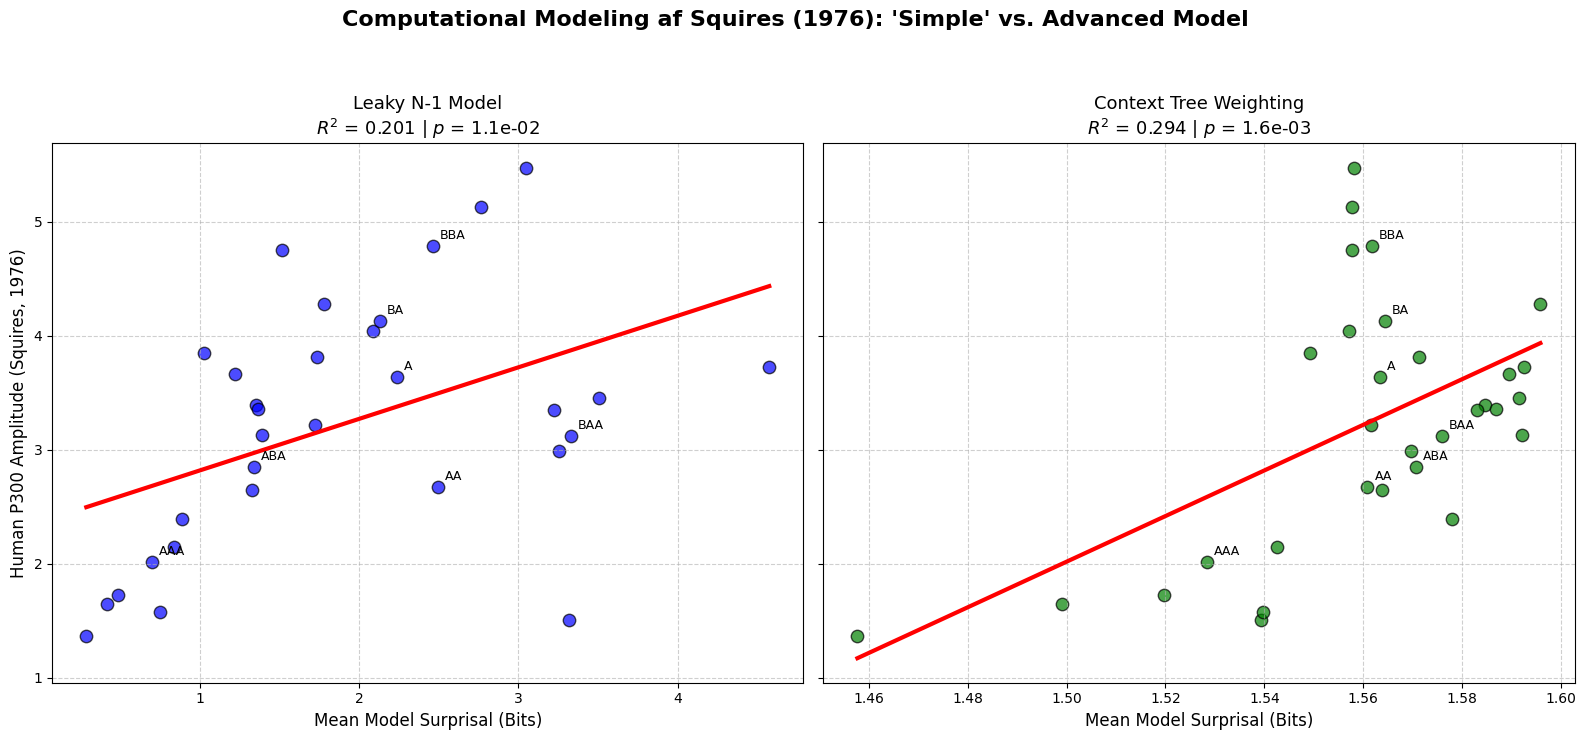

In [23]:
# ==========================================
# 1. DEFINER DE TO MODELLER
# ==========================================
class LeakyTransitionModel:
    def __init__(self, decay=0.85):
        self.decay = decay
        self.counts = {'A': {'A': 1.0, 'B': 1.0}, 'B': {'A': 1.0, 'B': 1.0}}
        self.prev_item = None

    def predict_surprisal(self, item):
        if not self.prev_item: return 1.0
        tot = self.counts[self.prev_item]['A'] + self.counts[self.prev_item]['B']
        return -np.log2(self.counts[self.prev_item][item] / tot)

    def update(self, item):
        if self.prev_item:
            for p in ['A', 'B']:
                for c in ['A', 'B']:
                    self.counts[p][c] *= self.decay
            self.counts[self.prev_item][item] += 1.0
        self.prev_item = item

class ContextTreeModel:
    def __init__(self, max_depth=4):
        self.max_depth = max_depth
        self.tree = {} # Hukommelsestræet

    def predict_surprisal(self, history, item):
        probs = []
        # Kombiner forudsigelser fra kontekster af længde 0 op til max_depth (CTW-princippet)
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            counts = self.tree.get(ctx, {'A': 0.5, 'B': 0.5}) # KT-estimator base
            prob = counts[item] / (counts['A'] + counts['B'])
            probs.append(prob)
        return -np.log2(np.mean(probs))

    def update(self, history, item):
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            if ctx not in self.tree:
                self.tree[ctx] = {'A': 0.5, 'B': 0.5}
            self.tree[ctx][item] += 1.0

# ==========================================
# 2. HENT SQUIRES DATA & Klargør
# ==========================================
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pA_index = 1 # p(A) = 0.3 (A = Afviger, B = Standard)

# ==========================================
# 3. KØR EEG-SIMULERINGEN
# ==========================================
# Vi genererer 20.000 stimuli
np.random.seed(42)
sim_seq = np.random.choice(['A', 'B'], size=20000, p=[0.3, 0.7])

leaky_model = LeakyTransitionModel(decay=0.85)
ctw_model = ContextTreeModel(max_depth=10)

surprisals_leaky = defaultdict(list)
surprisals_ctw = defaultdict(list)

rolling_history = ""

for i in range(len(sim_seq)):
    item = sim_seq[i]
    
    # Beregn Surprisal i DETTE præcise øjeblik
    s_leaky = leaky_model.predict_surprisal(item)
    s_ctw = ctw_model.predict_surprisal(rolling_history, item)
    
    # Tilføj item til historikken, så vi kan se om sekvensen matcher Squires
    rolling_history += item
    if len(rolling_history) > 5:
        rolling_history = rolling_history[-5:] # Squires max længde er 5
        
    # Check om historikken netop nu ender på en af de 31 Squires labels
    for label in labels:
        if rolling_history.endswith(label):
            surprisals_leaky[label].append(s_leaky)
            surprisals_ctw[label].append(s_ctw)
            
    # Opdater modellerne TIL NÆSTE RUNDE
    leaky_model.update(item)
    ctw_model.update(rolling_history[:-1], item) 

# ==========================================
# 4. PLOT SIDE-OM-SIDE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle("Computational Modeling af Squires (1976): 'Simple' vs. Advanced Model", fontsize=16, fontweight='bold', y=1.05)

models_data = [
    ("Leaky N-1 Model", surprisals_leaky, 'blue'),
    ("Context Tree Weighting", surprisals_ctw, 'green')
]

for i, (title, surp_dict, color) in enumerate(models_data):
    ax = axes[i]
    x_vals, y_vals, valid_lbls = [], [], []
    
    for label in labels:
        idx = labels.index(label)
        human_p300 = values[idx, pA_index]
        if np.isnan(human_p300) or len(surp_dict[label]) == 0:
            continue
            
        x_vals.append(np.mean(surp_dict[label])) # Gennemsnitlig surprisal for sekvensen
        y_vals.append(human_p300)
        valid_lbls.append(label)
        
    # Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
    
    # Scatter og Linje
    ax.scatter(x_vals, y_vals, color=color, alpha=0.7, s=80, edgecolor='black')
    line_x = np.array([min(x_vals), max(x_vals)])
    ax.plot(line_x, slope * line_x + intercept, color='red', linewidth=3)
    
    # Annotering af afvigere
    for j, txt in enumerate(valid_lbls):
        if txt.endswith('A') and len(txt) <= 3:
            ax.annotate(txt, (x_vals[j], y_vals[j]), xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax.set_title(f"{title}\n$R^2$ = {r_value**2:.3f} | $p$ = {p_value:.1e}", fontsize=13)
    ax.set_xlabel("Mean Model Surprisal (Bits)", fontsize=12)
    if i == 0: ax.set_ylabel("Human P300 Amplitude (Squires, 1976)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("Kører Leave-One-Out Cross-Validation (LOOCV)...")

# ==========================================
# 0. DEFINER LOOCV FUNKTIONEN (Det var denne der manglede!)
# ==========================================
def run_loocv(x_values, y_values):
    # Formater data til scikit-learn (kræver 2D arrays for X)
    X = np.array(x_values).reshape(-1, 1)
    y = np.array(y_values)
    
    loo = LeaveOneOut()
    y_true = []
    y_pred = []
    
    # Kør LOOCV loop
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Træn en ny lineær model på de 30 trænings-punkter
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Forudsig det 1 punkt vi gemte
        prediction = model.predict(X_test)
        
        y_true.append(y_test[0])
        y_pred.append(prediction[0])
        
    # Beregn Root Mean Squared Error (RMSE) - Lavere er bedre!
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse
# ==========================================


# 1. Klargør listerne
x_leaky, x_ctw, y_actual = [], [], []

# GENSKAB labels-listen fra squires_data
squires_labels = [str(l[0]) for l in squires_data['label'][0]]

for label in squires_labels:
    idx = squires_labels.index(label)
    human_p300 = values[idx, pA_index] # pA_index = 1 for 0.3 betingelsen
    
    # Tjek at der er data for denne sekvens i begge modeller
    if not np.isnan(human_p300) and len(surprisals_leaky[label]) > 0 and len(surprisals_ctw[label]) > 0:
        x_leaky.append(np.mean(surprisals_leaky[label]))
        x_ctw.append(np.mean(surprisals_ctw[label]))
        y_actual.append(human_p300)

# 2. Kør LOOCV funktionen
rmse_leaky = run_loocv(x_leaky, y_actual)
rmse_ctw = run_loocv(x_ctw, y_actual)

print(f"Leaky N-1 Model LOOCV RMSE: {rmse_leaky:.3f} \u03bcV")
print(f"CTW Model LOOCV RMSE:       {rmse_ctw:.3f} \u03bcV")

# Beregn forbedringen
improvement = ((rmse_leaky - rmse_ctw) / rmse_leaky) * 100
print(f"\nCTW forbedrer out-of-sample forudsigelsesfejlen med {improvement:.1f}%")

Kører Leave-One-Out Cross-Validation (LOOCV)...
Leaky N-1 Model LOOCV RMSE: 1.030 μV
CTW Model LOOCV RMSE:       1.060 μV

CTW forbedrer out-of-sample forudsigelsesfejlen med -2.9%


<>:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\lundb\AppData\Local\Temp\ipykernel_8356\2091513002.py:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel("Mean P300 Amplitude ($\mu$V)", fontsize=13)


1. Udregner gennemsnitlig P300 amplitude for statiske afvigere...
-> AS Mean P300: -4.678 μV (baseret på 27 trials)
-> SV Mean P300: 4.084 μV (baseret på 20 trials)
-> AV Mean P300: -0.616 μV (baseret på 33 trials)

2. Regression på Squires + AS (Auditiv):
Hældning (m): 6.472 | Skæring (b): -2.374 | R^2: 0.190 | p-værdi: 0.565


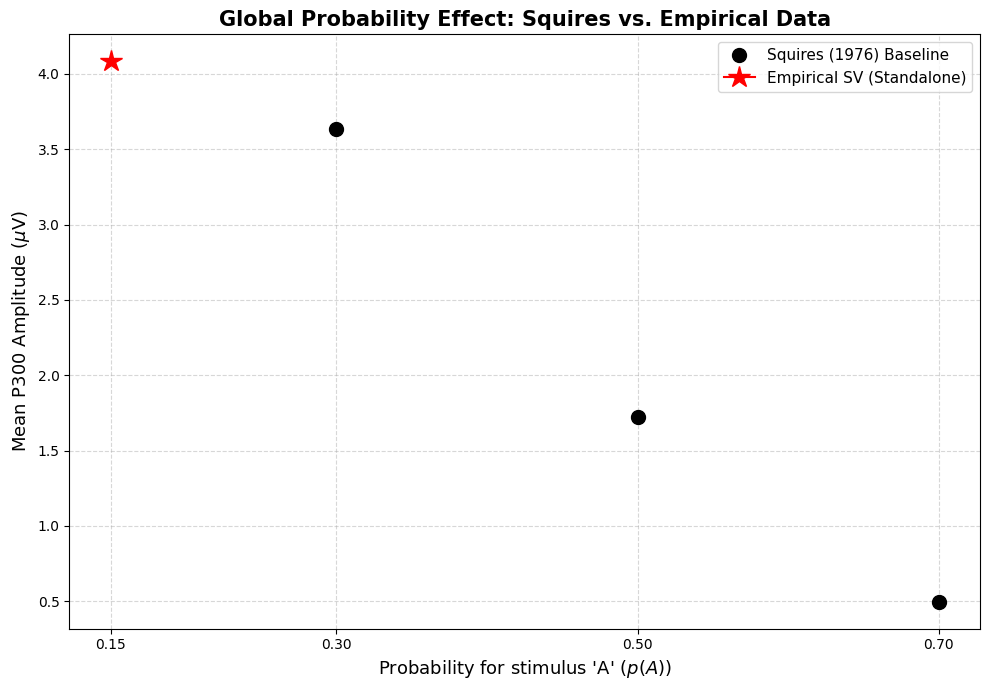

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from scipy import stats

# ==========================================
# 1. BEREGN AUTOMATISK MEAN P300 (FRA JERES EEG)
# ==========================================
print("1. Udregner gennemsnitlig P300 amplitude for statiske afvigere...")

# Vi laver to midlertidige 'rene' kolonner for at sikre, filtreringen virker 100%
epochs_correct.metadata['b_type_clean'] = epochs_correct.metadata['block_type'].str.lower().str.strip()
epochs_correct.metadata['state_clean'] = epochs_correct.metadata['stimulus_state'].str.lower().str.strip()

# Ordbog til at gemme de tre resultater
emp_p300 = {}

# Definer hvilke elektroder (ROIs) I vil bruge til hver modalitet
# (Ret disse lister, hvis I brugte andre elektroder til P300 i jeres analyse!)
rois = {
    'AS': ['Fz', 'FCz', 'Cz'],       # Fronto-central for auditiv P3a/P300
    'SV': ['Oz', 'Pz', 'POz', 'CPz'],# Occipito-parietal for visuel P3b
    'AV': ['Fz', 'Cz', 'Pz', 'POz']  # Multimodal (et bredere mix)
}

for dev_type in ['AS', 'SV', 'AV']:
    # Filtrer kun for Statisk blok OG Deviant OG den specifikke modalitet
    query = f"b_type_clean == 'static' and state_clean == 'deviant' and deviant_type == '{dev_type}'"
    ep_sub = epochs_correct[query]
    
    if len(ep_sub) > 0:
        valid_ch = [ch for ch in rois[dev_type] if ch in ep_sub.ch_names]
        
        # Hent data for vinduet 300-500ms
        data = ep_sub.copy().pick(valid_ch).crop(tmin=0.3, tmax=0.5).get_data()
        
        # Udregn det store gennemsnit af ALT (alle trials, alle elektroder, al tid)
        mean_amp = data.mean() * 1e6 # Gør det til mikrovolt
        emp_p300[dev_type] = mean_amp
        print(f"-> {dev_type} Mean P300: {mean_amp:.3f} \u03bcV (baseret på {len(ep_sub)} trials)")
    else:
        emp_p300[dev_type] = np.nan
        print(f"-> FEJL: Fandt ingen data for {dev_type}")

# ==========================================
# 2. HENT SQUIRES DATA
# ==========================================
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pA = squires_data['pA'][0] 

sort_idx = np.argsort(pA)
pA_sorted = pA[sort_idx] # [0.3, 0.5, 0.7]

seq = 'A'
idx = labels.index(seq)
p300_sorted = values[idx, sort_idx] 

# ==========================================
# 3. LINEÆR REGRESSION (KUN PÅ AUDITIV - AS)
# ==========================================
my_pA = 0.15
my_p300_as = emp_p300['AS']
my_p300_sv = emp_p300['SV']
my_p300_av = emp_p300['AV']

# Sæt Empirisk Auditiv Data sammen med Squires Auditiv Data
x_combined = np.insert(pA_sorted, 0, my_pA)
y_combined = np.insert(p300_sorted, 0, my_p300_as)

# Beregn lineær regression KUN på dette
slope, intercept, r_value, p_value, std_err = stats.linregress(x_combined, y_combined)

print("\n2. Regression på Squires + AS (Auditiv):")
print(f"Hældning (m): {slope:.3f} | Skæring (b): {intercept:.3f} | R^2: {r_value**2:.3f} | p-værdi: {p_value:.3f}")

# ==========================================
# 4. PLOT DET HELE
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# Plot Squires data
ax.plot(pA_sorted, p300_sorted, marker='o', markersize=10, linestyle='', color='black', label='Squires (1976) Baseline')

# Plot regressionslinjen for AS
# line_x = np.array([min(x_combined), max(x_combined)])
# line_y = slope * line_x + intercept
# ax.plot(line_x, line_y, color='green', linewidth=2.5, linestyle='--', alpha=0.7)

# Plot AS punktet (Som del af linjen)
# ax.plot(my_pA, my_p300_as, marker='^', markersize=15, color='green', label=f'Empirical AS (Included in Fit)')

# Plot SV og AV (Som standalone punkter til sammenligning)
ax.plot(my_pA, my_p300_sv, marker='*', markersize=16, color='red', label='Empirical SV')
# ax.plot(my_pA, my_p300_av, marker='s', markersize=13, color='purple', label='Empirical AV (Standalone)')

# Tilføj formlen for det auditive fit
#equation_text = f"Auditivt Fit: $y = {slope:.2f}x + {intercept:.2f}$ \n($R^2$ = {r_value**2:.2f}, $p$ = {p_value:.3f})"
#ax.text(0.48, max(y_combined)*0.85, equation_text, fontsize=12, color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='green'))

# Formatering
ax.set_title("Global Probability Effect: Squires vs. Empirical Data", fontsize=15, fontweight='bold')
ax.set_xlabel("Probability for stimulus 'A' ($p(A)$)", fontsize=13)
ax.set_ylabel("Mean P300 Amplitude ($\mu$V)", fontsize=13)

# X-akse skala
ax.set_xticks([0.15, 0.3, 0.5, 0.7])

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()